In [214]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [215]:
X, y = make_blobs(
  n_samples=1000,
  centers=3,
  n_features=2
)

In [216]:
pd.DataFrame(X)

,0,1
0,9.853494,5.774066
1,-7.734447,-8.488817
2,-7.571838,-7.945203
3,-8.605703,-6.355310
4,-4.449617,6.838692
...,...,...
995,9.946866,6.046473
996,9.871334,5.497783
997,9.434864,6.064888
998,-6.788779,-7.631210


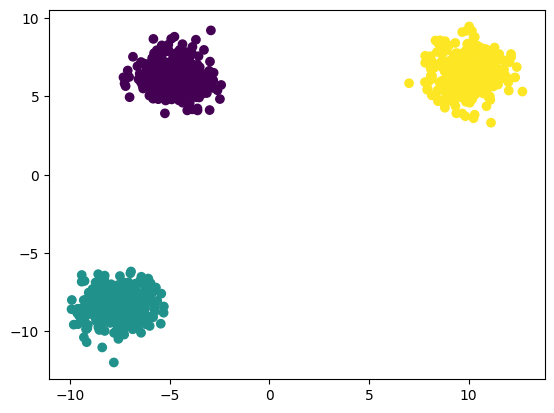

In [217]:
plt.scatter(X[:,0], X[:,1], c=y)

In [218]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [219]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(  ## obv we don't need y_train and y_test 
  X, y, test_size=0.33, random_state=42
)

In [220]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [221]:
from sklearn.cluster import KMeans

In [222]:
## Elbow method to select K-value
wcss = []
for k in range(1,11):
    kmeans = KMeans(
      n_clusters = k,
      init = "k-means++"
    )

    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

In [223]:
wcss

[1339.9999999999995,
 424.04199606105533,
 23.153192113564433,
 19.646526461302486,
 17.13449577786245,
 14.612630803065644,
 12.736482074495964,
 11.200016683175297,
 9.708812097363612,
 8.688468087767479]

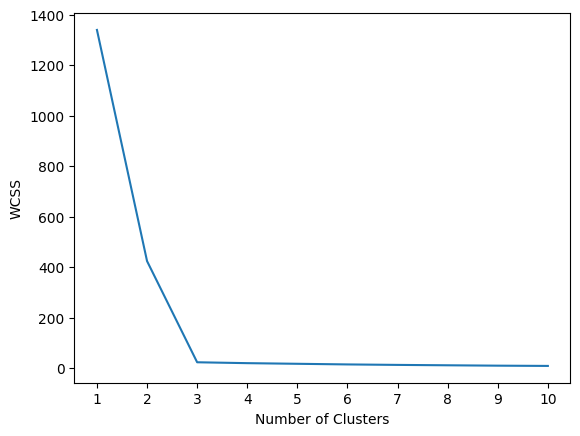

In [224]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [225]:
kmeans.fit_predict(X_train_scaled)

c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([8, 0, 1, 9, 3, 9, 3, 7, 3, 8, 4, 1, 2, 2, 6, 7, 0, 2, 4, 5, 5, 7,
       4, 6, 3, 1, 1, 2, 8, 5, 2, 8, 6, 0, 0, 6, 8, 4, 3, 7, 1, 2, 1, 9,
       4, 5, 9, 8, 9, 1, 9, 7, 8, 4, 4, 4, 8, 9, 8, 4, 3, 7, 1, 1, 2, 3,
       5, 1, 8, 8, 1, 3, 7, 8, 1, 4, 3, 8, 2, 8, 2, 9, 6, 8, 6, 6, 0, 0,
       4, 6, 1, 6, 2, 1, 7, 2, 5, 4, 5, 4, 3, 4, 9, 6, 3, 7, 7, 7, 3, 1,
       1, 9, 0, 3, 7, 5, 5, 4, 3, 6, 4, 6, 8, 8, 4, 6, 7, 3, 9, 9, 8, 2,
       1, 8, 4, 9, 9, 0, 1, 1, 1, 1, 0, 5, 3, 0, 5, 1, 4, 8, 6, 6, 1, 3,
       6, 1, 5, 7, 1, 9, 1, 8, 5, 0, 1, 3, 5, 8, 9, 5, 9, 2, 8, 6, 8, 1,
       5, 8, 5, 7, 8, 3, 6, 2, 5, 6, 7, 4, 7, 4, 5, 7, 2, 2, 5, 4, 2, 7,
       8, 8, 0, 3, 0, 2, 3, 7, 2, 4, 9, 0, 6, 4, 1, 3, 6, 4, 5, 5, 0, 8,
       1, 8, 4, 2, 9, 4, 4, 2, 1, 9, 2, 3, 2, 3, 7, 3, 2, 0, 5, 8, 9, 1,
       8, 5, 1, 1, 6, 7, 3, 9, 4, 8, 1, 0, 7, 4, 0, 4, 1, 9, 4, 1, 4, 9,
       6, 4, 9, 8, 2, 2, 2, 7, 0, 6, 8, 4, 1, 0, 6, 1, 5, 5, 0, 8, 1, 7,
       7, 2, 6, 9, 4, 5, 3, 2, 3, 7, 5, 9, 0, 8, 8,

In [226]:
X_test_pred = kmeans.predict(X_test_scaled)

In [227]:
X_test_pred

array([4, 1, 8, 3, 2, 0, 2, 1, 9, 5, 6, 1, 7, 2, 4, 7, 1, 7, 7, 5, 1, 7,
       5, 4, 2, 1, 1, 8, 6, 8, 7, 4, 4, 1, 5, 5, 2, 6, 1, 6, 6, 6, 9, 1,
       1, 8, 1, 1, 1, 9, 4, 6, 4, 2, 6, 4, 6, 5, 4, 3, 5, 2, 6, 7, 5, 2,
       9, 7, 7, 1, 5, 9, 5, 2, 1, 5, 4, 1, 1, 5, 6, 8, 3, 9, 5, 7, 1, 5,
       1, 1, 6, 9, 9, 4, 3, 8, 5, 3, 7, 0, 4, 1, 8, 2, 9, 1, 7, 5, 7, 2,
       3, 1, 2, 2, 2, 2, 8, 3, 5, 1, 2, 2, 2, 6, 2, 7, 7, 4, 1, 2, 8, 8,
       9, 8, 6, 6, 8, 5, 1, 5, 2, 9, 7, 9, 3, 6, 1, 1, 1, 9, 5, 9, 1, 1,
       0, 0, 1, 2, 2, 9, 3, 7, 2, 8, 8, 6, 8, 9, 4, 8, 3, 7, 7, 1, 6, 1,
       0, 0, 1, 9, 2, 8, 6, 6, 5, 9, 3, 3, 7, 8, 9, 0, 2, 2, 6, 5, 4, 4,
       7, 6, 6, 2, 9, 6, 0, 7, 1, 4, 9, 1, 3, 6, 0, 9, 4, 7, 9, 3, 4, 3,
       6, 6, 1, 7, 3, 1, 7, 2, 7, 0, 7, 8, 9, 6, 5, 2, 2, 5, 4, 4, 4, 8,
       6, 3, 0, 0, 4, 1, 2, 2, 8, 9, 0, 4, 7, 9, 7, 1, 5, 8, 4, 7, 0, 9,
       5, 5, 5, 4, 4, 9, 7, 1, 6, 2, 5, 5, 1, 3, 6, 3, 8, 4, 5, 6, 4, 8,
       2, 6, 4, 8, 7, 5, 0, 7, 6, 4, 2, 4, 7, 1, 6,

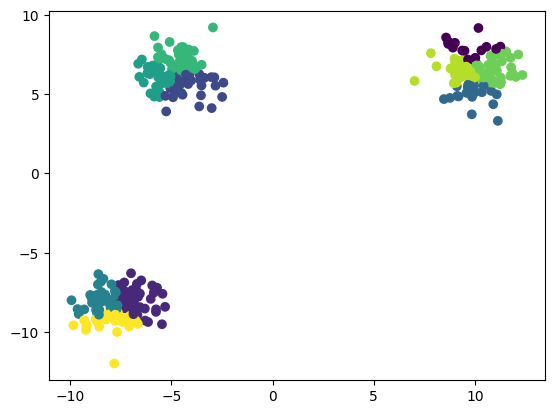

In [228]:
plt.scatter(X_test[:,0], X_test[:,1], c=X_test_pred)

# Validating the k-value
## 1. Knee Locator (good)
## 2. Silhouette Scoring (also good)

### 1. Knee Locator

In [229]:
# Knee Locator
!pip install kneed


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [231]:
from kneed import KneeLocator

kl = KneeLocator(
  range(1, 11),
  wcss,
  curve = "convex",
  direction = "decreasing" ## in our case of values they are decreasing for wcss we can see
)

In [232]:
kl.elbow

3

### 2. Silhoutte Scoring

In [ ]:
from sklearn.metrics import silhouette_score

In [240]:
silhouette_coefficients = []

for k in range(2, 11):
    kmeans = KMeans(
      n_clusters = k,
      init = "k-means++",
    )
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\ayush\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

In [241]:
silhouette_coefficients

[0.687690432826725,
 0.8799939473293239,
 0.6946127656940927,
 0.5173631305315627,
 0.3283815381344611,
 0.34004529474516804,
 0.3413512942602859,
 0.3553406273334608,
 0.35824208291814]

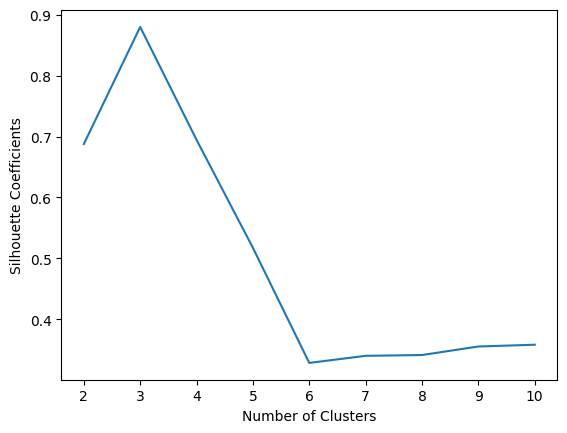

In [242]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficients")
plt.show()